# Formula 1 World Championship (1950 - 2024) analysis

### Team victory by decade

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_35690/3203980931.py:4: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


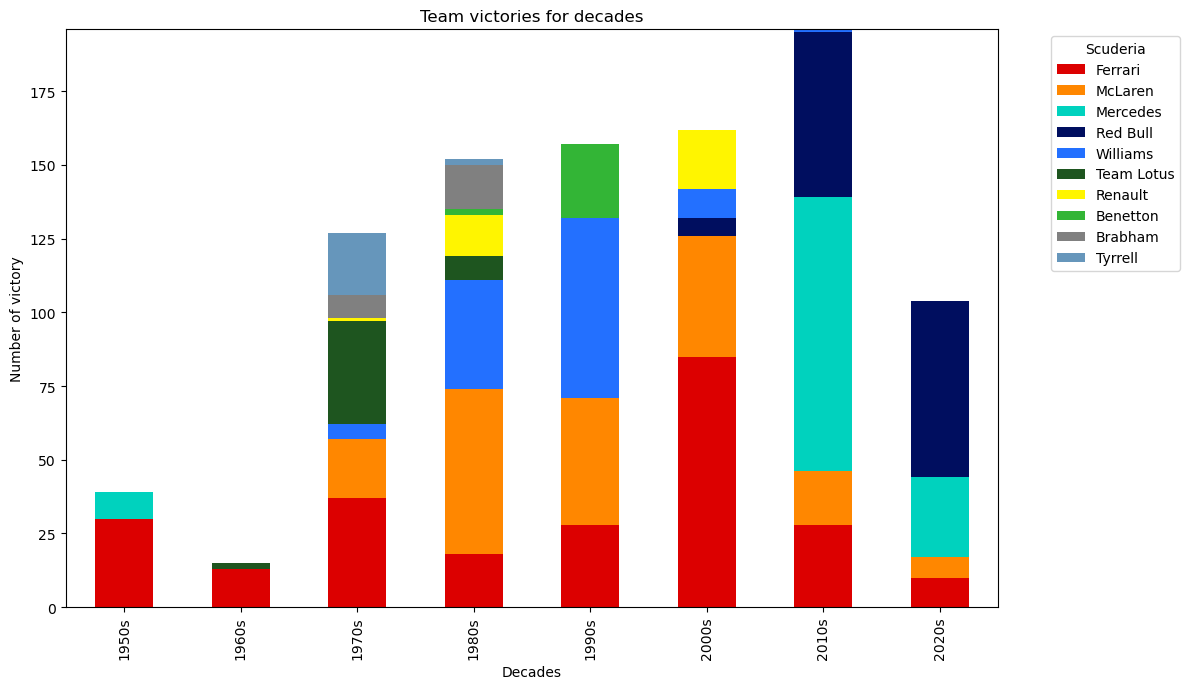

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")

winners = df[df["finish_position"] == 1].copy()

winners["decade"] = (winners["year"] // 10) * 10

wins_by_decade = winners.groupby(["decade", "constructor_name"]).size().unstack(fill_value=0)

top_teams = wins_by_decade.sum().sort_values(ascending=False).head(10).index
wins_by_decade = wins_by_decade[top_teams]

wins_by_decade.index = [f"{d}s" for d in wins_by_decade.index]

colors = {
    "Ferrari": "#DC0000",      # rosso Ferrari
    "Red Bull": "#000E5F",     # blu Red Bull
    "Mercedes": "#00D2BE",     # azzurro Mercedes
    "Renault": "#FFF500",      # giallo Renault
    "Williams": "#2370FF",     # blu Williams (diverso!)
    "McLaren": "#FF8700",
    "Team Lotus": "#1E551F",
    "Benetton": "#33B536",
    "Brabham": "gray",
    "Tyrrell": "#6696BB"
}

default_colors = plt.cm.tab20.colors
color_list = []

for i, team in enumerate(wins_by_decade.columns):
    if team in colors:
        color_list.append(colors[team])
    else:
        color_list.append(default_colors[i % len(default_colors)])

wins_by_decade.plot(kind="bar", stacked=True, figsize=(12,7), color=color_list)

plt.xlabel("Decades")
plt.ylabel("Number of victory")
plt.title("Team victories for decades")

plt.legend(title="Scuderia", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

### Fastest circuits

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_34458/2140369155.py:5: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


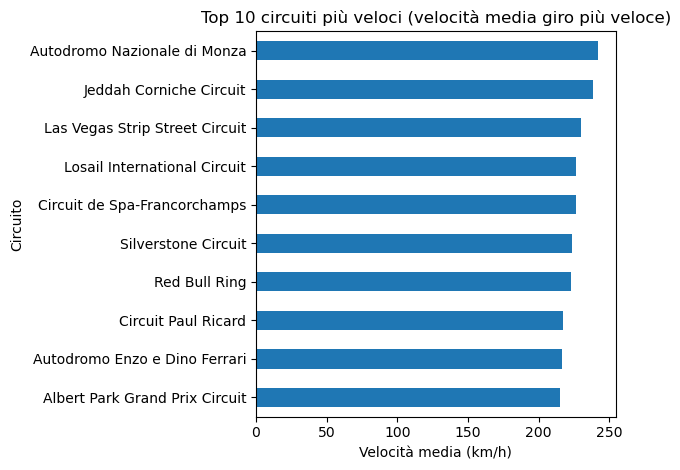

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica il dataset (modifica il percorso se serve)
df = pd.read_csv("mainDataset.csv")

# Pulizia base: rimuove valori mancanti
df = df.dropna(subset=["circuit_name", "fastest_lap_speed_kmh"])

# Calcola la velocità media per circuito
fastest_circuits = (
    df.groupby("circuit_name")["fastest_lap_speed_kmh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure()
fastest_circuits.sort_values().plot(kind="barh")

plt.title("Top 10 circuiti più veloci (velocità media giro più veloce)")
plt.xlabel("Velocità media (km/h)")
plt.ylabel("Circuito")

plt.tight_layout()
plt.show()

---

### Fastest lap evolution

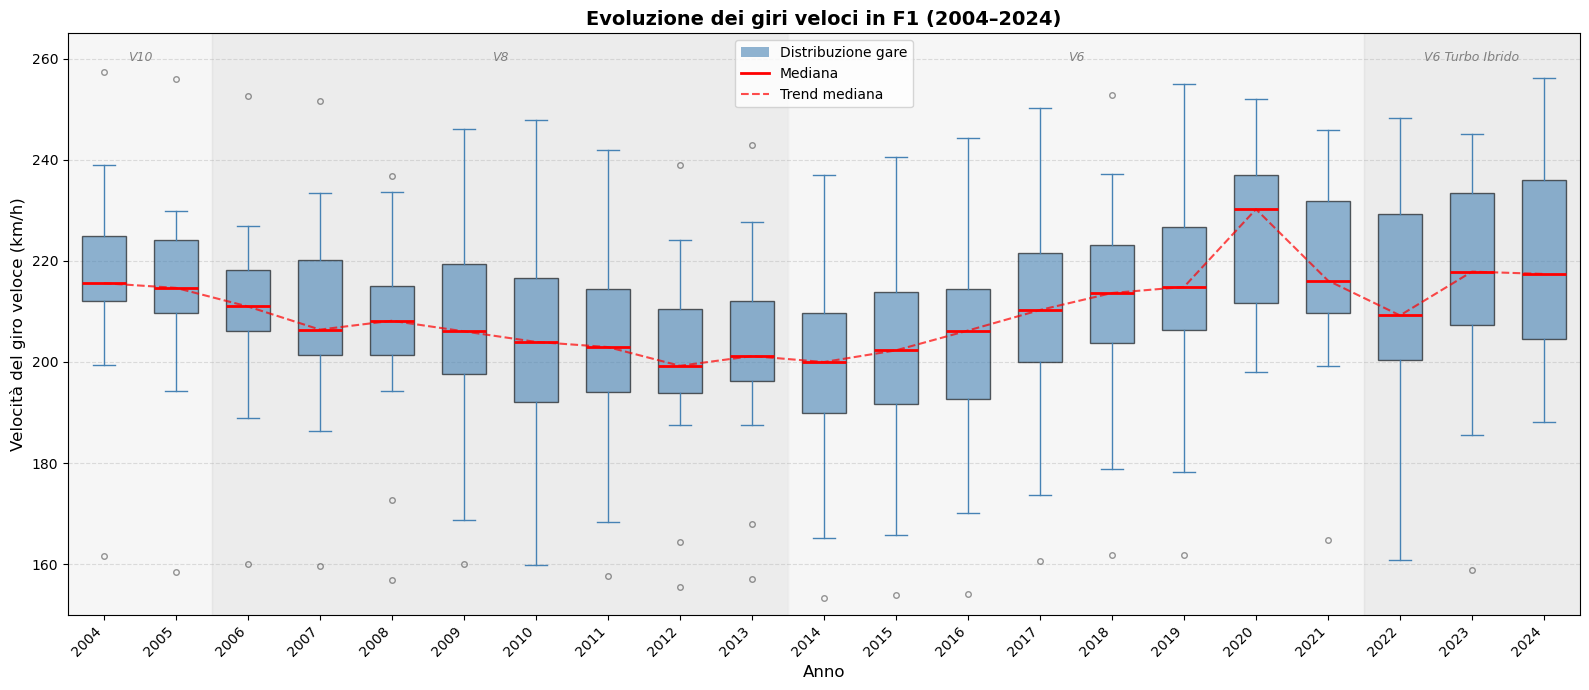

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Caricamento dati ---
df = pd.read_csv("mainDataset.csv", low_memory=False)

df = df[df["fastest_lap_rank"] == 1].dropna(subset=["fastest_lap_speed_kmh", "year"])
df["year"] = df["year"].astype(int)

years = sorted(df["year"].unique())
data_by_year = [df[df["year"] == y]["fastest_lap_speed_kmh"].values for y in years]

# --- Ere regolamentari ---
eras = [
    (2004, 2005, "V10"),
    (2006, 2013, "V8"),
    (2014, 2021, "V6"),
    (2022, 2024, "V6 Turbo Ibrido"),
]
era_colors = ["#f0f0f0", "#e0e0e0", "#f0f0f0", "#e0e0e0"]

# --- Grafico ---
fig, ax = plt.subplots(figsize=(16, 7))

# Sfondo per ogni era
for (start, end, label), color in zip(eras, era_colors):
    ax.axvspan(years.index(start) + 0.5, years.index(end) + 1.5,
               color=color, alpha=0.6, zorder=0)
    mid_idx = (years.index(start) + years.index(end)) / 2 + 1
    ax.text(mid_idx, 0.97, label,
            ha="center", va="top", fontsize=9, color="gray", style="italic",
            transform=ax.get_xaxis_transform())

# Boxplot
bp = ax.boxplot(data_by_year,
                positions=range(1, len(years) + 1),
                widths=0.6,
                patch_artist=True,
                medianprops=dict(color="red", linewidth=2),
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                whiskerprops=dict(color="steelblue"),
                capprops=dict(color="steelblue"),
                flierprops=dict(marker="o", color="steelblue", alpha=0.4,
                                markersize=4, linestyle="none"))

# Linea della mediana annuale
medians = [np.median(d) for d in data_by_year]
ax.plot(range(1, len(years) + 1), medians,
        color="red", linewidth=1.5, linestyle="--",
        marker="", alpha=0.7, label="Mediana annuale")

# --- Etichette e titolo ---
ax.set_xlabel("Anno", fontsize=12)
ax.set_ylabel("Velocità del giro veloce (km/h)", fontsize=12)
ax.set_title("Evoluzione dei giri veloci in F1 (2004–2024)", fontsize=14, fontweight="bold")

ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(years, rotation=45, ha="right")
ax.set_ylim(150, 265)

ax.grid(axis="y", linestyle="--", alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", alpha=0.6, label="Distribuzione gare"),
    plt.Line2D([0], [0], color="red", linewidth=2, label="Mediana"),
    plt.Line2D([0], [0], color="red", linewidth=1.5, linestyle="--", alpha=0.7, label="Trend mediana"),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig("FastlapEvolution_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


### Pitstops by year

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_34458/4096950641.py:5: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


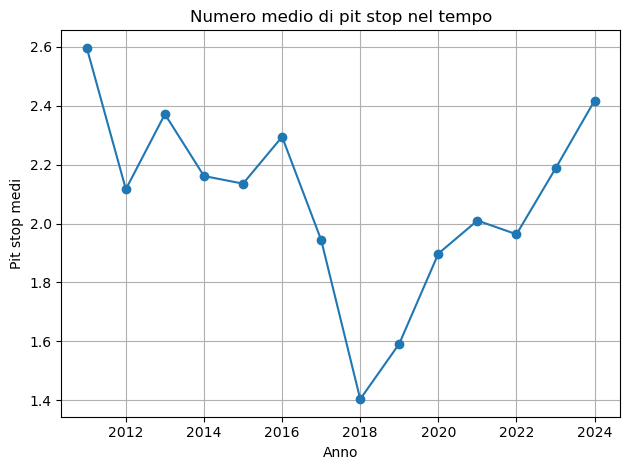

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica il dataset
df = pd.read_csv("mainDataset.csv")

# Pulizia: rimuove valori mancanti
df = df.dropna(subset=["year", "pit_stop_count"])

# Calcola media pit stop per anno
pitstop_trend = (
    df.groupby("year")["pit_stop_count"]
    .mean()
    .sort_index()
)

# Grafico
plt.figure()
pitstop_trend.plot(marker='o')

plt.title("Numero medio di pit stop nel tempo")
plt.xlabel("Anno")
plt.ylabel("Pit stop medi")

plt.grid(True)
plt.tight_layout()
plt.show()

---

### Relation between qualify result and race result

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_34458/3089263834.py:6: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


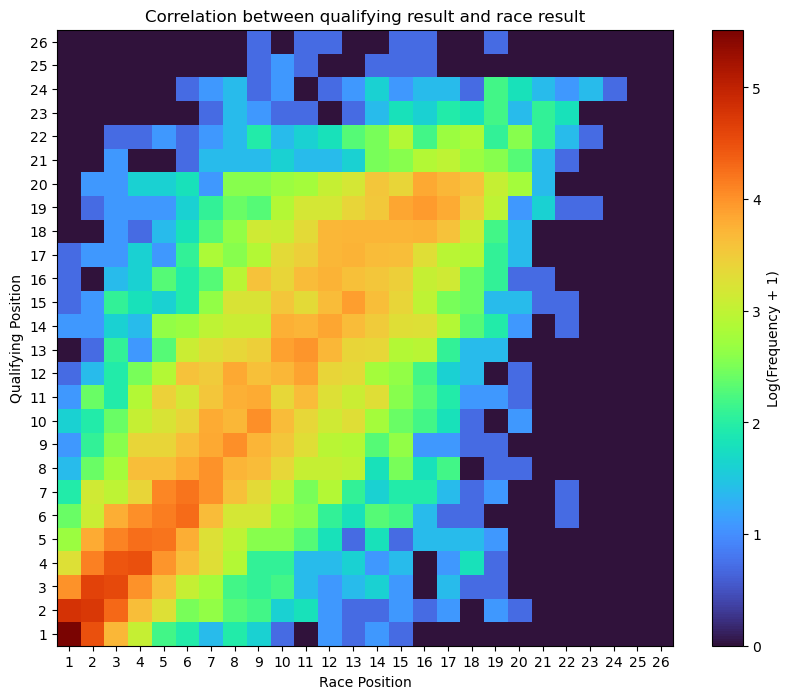

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("mainDataset.csv")

df = df[['quali_position', 'finish_position']].dropna()

df['quali_position'] = pd.to_numeric(df['quali_position'], errors='coerce')
df['finish_position'] = pd.to_numeric(df['finish_position'], errors='coerce')

df = df.dropna()

df = df[(df['quali_position'] >= 1) & (df['quali_position'] <= 30)]
df = df[(df['finish_position'] >= 1) & (df['finish_position'] <= 30)]

heatmap = pd.crosstab(df['quali_position'], df['finish_position'])

heatmap = heatmap.reindex(index=range(1,27), columns=range(1,27), fill_value=0)

data = np.log1p(heatmap)

# Plot
plt.figure(figsize=(10,8))
plt.imshow(data, cmap='turbo', origin='lower')  # <-- asse y parte dal basso

# Assi
plt.xticks(range(26), range(1,27))
plt.yticks(range(26), range(1,27))

plt.xlabel("Race Position")
plt.ylabel("Qualifying Position")
plt.title("Correlation between qualifying result and race result")

# (Opzionale ma consigliato) barra colori
plt.colorbar(label='Log(Frequency + 1)')

plt.show()

---

### Countries with most F1 Races

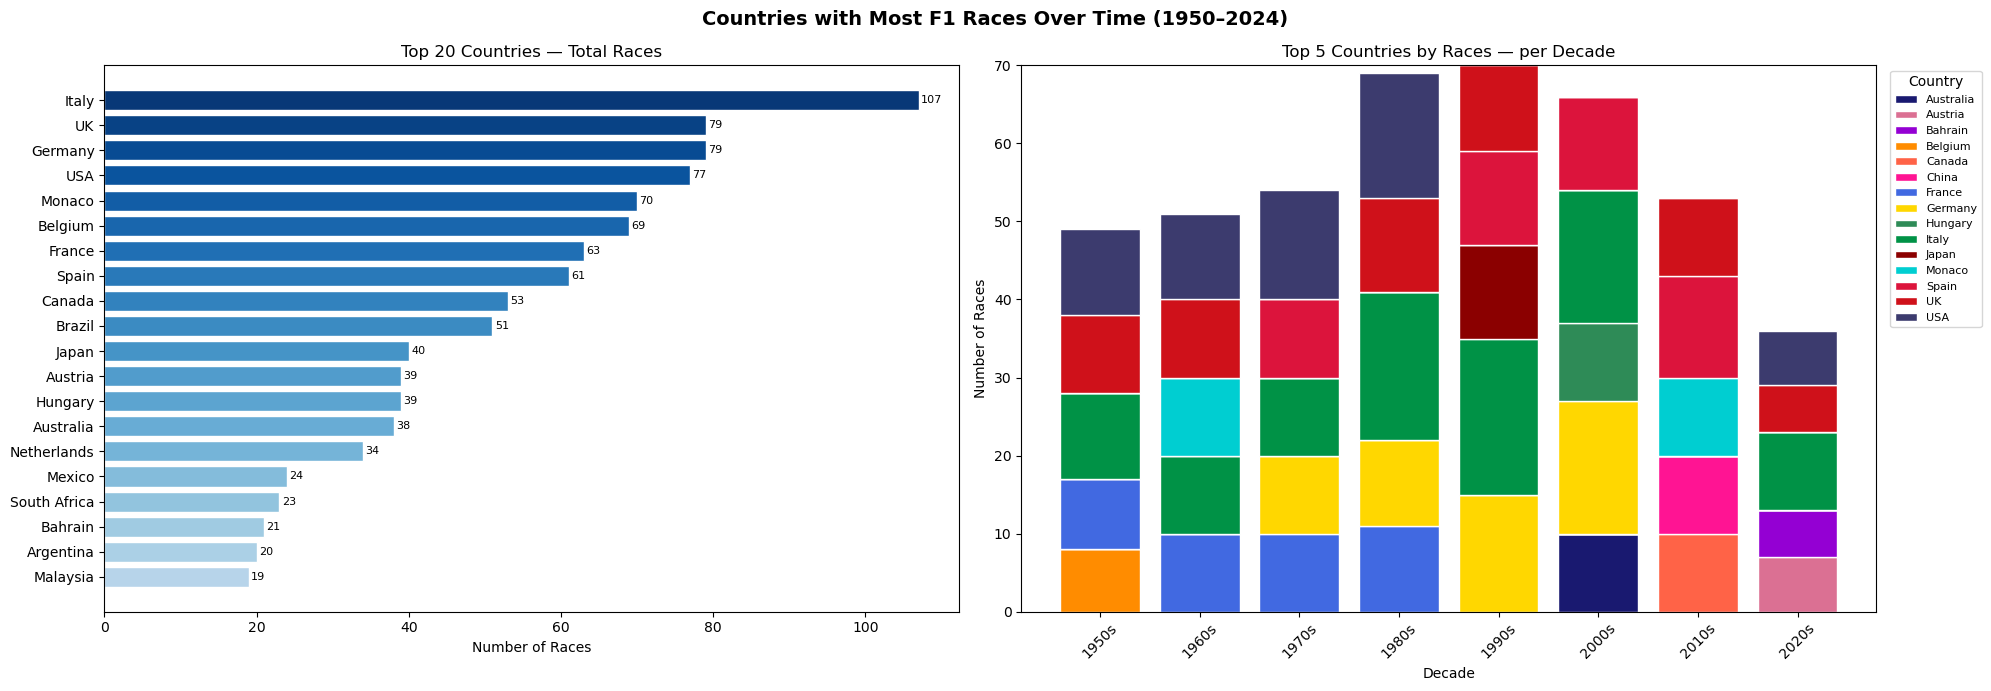

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
gare_uniche = df.drop_duplicates(subset="raceId")[["raceId", "country", "year"]]

races_per_country = (
    gare_uniche.groupby("country").size()
    .reset_index(name="n_races")
    .sort_values("n_races", ascending=False)
)

gare_uniche["decade"] = (gare_uniche["year"] // 10 * 10).astype(str) + "s"

races_per_decade = (
    gare_uniche.groupby(["country", "decade"]).size()
    .reset_index(name="n_races")
)

top5_per_decade = (
    races_per_decade.sort_values("n_races", ascending=False)
    .groupby("decade")
    .head(5)
)

pivot = (
    top5_per_decade.pivot(index="decade", columns="country", values="n_races")
    .fillna(0)
)

FLAG_COLORS = {
    "Italy":        "#009246",
    "Germany":      "#FFD700",
    "UK":           "#CF111A",
    "USA":          "#3C3B6E",
    "Monaco":       "#00CED1",
    "Belgium":      "#FF8C00",
    "France":       "#4169E1",
    "Spain":        "#DC143C",
    "Canada":       "#FF6347",
    "Brazil":       "#228B22",
    "Japan":        "#8B0000",
    "Austria":      "#DB7093",
    "Hungary":      "#2E8B57",
    "Australia":    "#191970",
    "Netherlands":  "#FF4500",
    "Mexico":       "#556B2F",
    "South Africa": "#DAA520",
    "Bahrain":      "#9400D3",
    "Argentina":    "#87CEEB",
    "Malaysia":     "#8B4513",
    "Switzerland":  "#A9A9A9",
    "Sweden":       "#4682B4",
    "Portugal":     "#006400",
    "China":        "#FF1493",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Countries with Most F1 Races Over Time (1950–2024)", fontsize=14, fontweight="bold")

# --- Chart 1: Top 20 total, all blue ---
top20 = races_per_country.head(20)
blues = plt.cm.Blues([0.3 + 0.7 * i / len(top20) for i in range(len(top20))])
bars = axes[0].barh(top20["country"][::-1], top20["n_races"][::-1], color=blues, edgecolor="white")
axes[0].set_title("Top 20 Countries — Total Races")
axes[0].set_xlabel("Number of Races")
for bar, val in zip(bars, top20["n_races"][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)

# --- Chart 2: Top 5 per decade ---
decades = sorted(pivot.index.tolist())
bottom = np.zeros(len(decades))
x = np.arange(len(decades))

for country in pivot.columns:
    values = [pivot.loc[d, country] if d in pivot.index else 0 for d in decades]
    if sum(values) == 0:
        continue
    color = FLAG_COLORS.get(country, "#AAAAAA")
    axes[1].bar(x, values, bottom=bottom, label=country, color=color, edgecolor="white")
    bottom += np.array(values)

axes[1].set_title("Top 5 Countries by Races — per Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Number of Races")
axes[1].set_xticks(x)
axes[1].set_xticklabels(decades, rotation=45)
axes[1].legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("races_per_country.png", dpi=150)
plt.show()

---

### Correlation between number of pitstops and final position

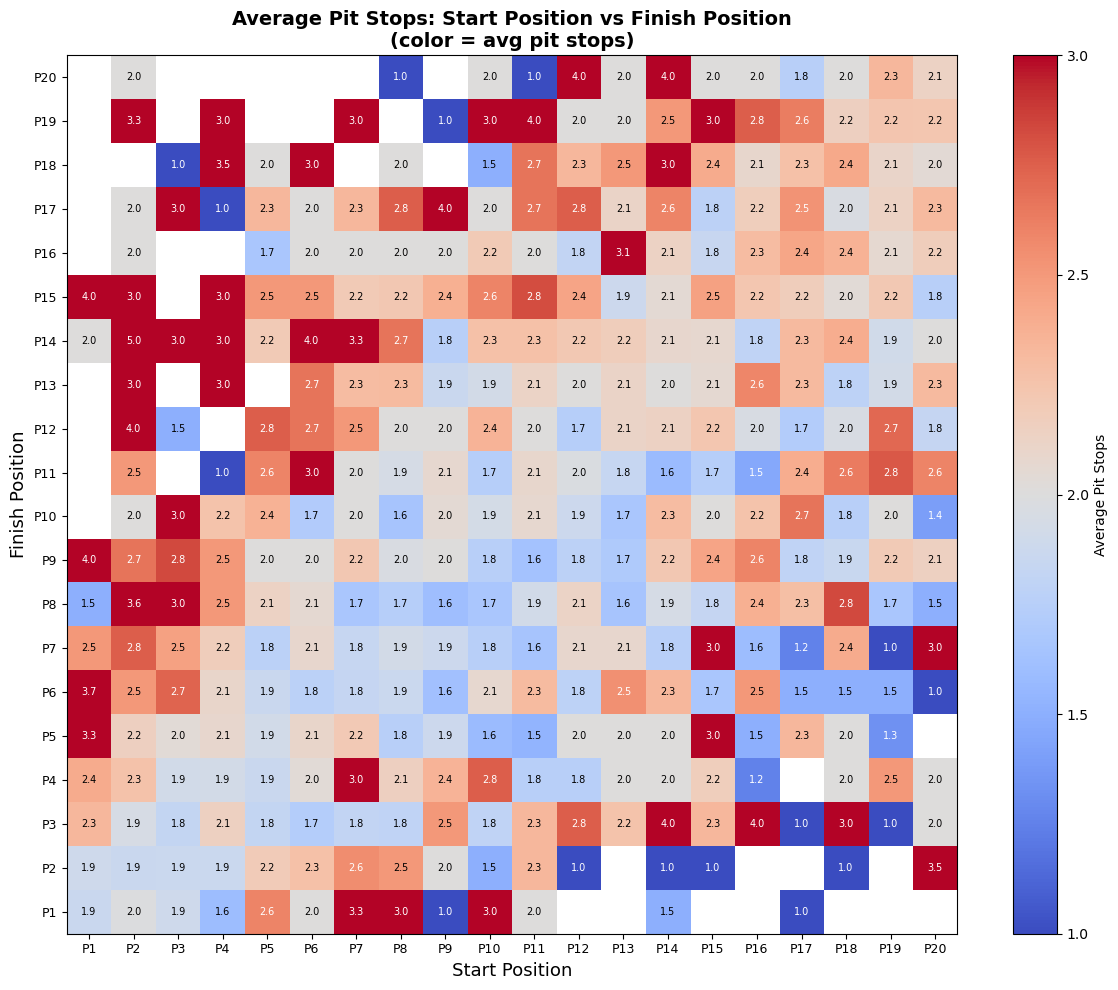

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
df_pit = df[["start_position", "finish_position", "pit_stop_count"]].dropna()

# Limita a valori sensati
df_pit = df_pit[
    (df_pit["start_position"].between(1, 20)) &
    (df_pit["finish_position"].between(1, 20)) &
    (df_pit["pit_stop_count"].between(1, 6))
]
df_pit["start_position"] = df_pit["start_position"].astype(int)
df_pit["finish_position"] = df_pit["finish_position"].astype(int)

# Matrice: media pit stop per ogni combinazione start/finish
heatmap_data = (
    df_pit.groupby(["finish_position", "start_position"])["pit_stop_count"]
    .mean()
    .unstack(fill_value=np.nan)
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(heatmap_data.values, cmap="coolwarm", aspect="auto",
               vmin=1, vmax=3)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f"P{int(c)}" for c in heatmap_data.columns], fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f"P{int(i)}" for i in heatmap_data.index], fontsize=9)

ax.set_xlabel("Start Position", fontsize=13)
ax.set_ylabel("Finish Position", fontsize=13)
ax.set_title("Average Pit Stops: Start Position vs Finish Position\n(color = avg pit stops)", fontsize=14, fontweight="bold")

ax.invert_yaxis()


# Valori nelle celle
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            color = "white" if (val > 2.5 or val < 1.5) else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7, color=color)

cbar = plt.colorbar(im, ax=ax, label="Average Pit Stops")
cbar.set_ticks([1, 1.5, 2, 2.5, 3])

plt.tight_layout()
plt.savefig("pit_stop_heatmap.png", dpi=150)
plt.show()

---

### Pilots with highest win rate

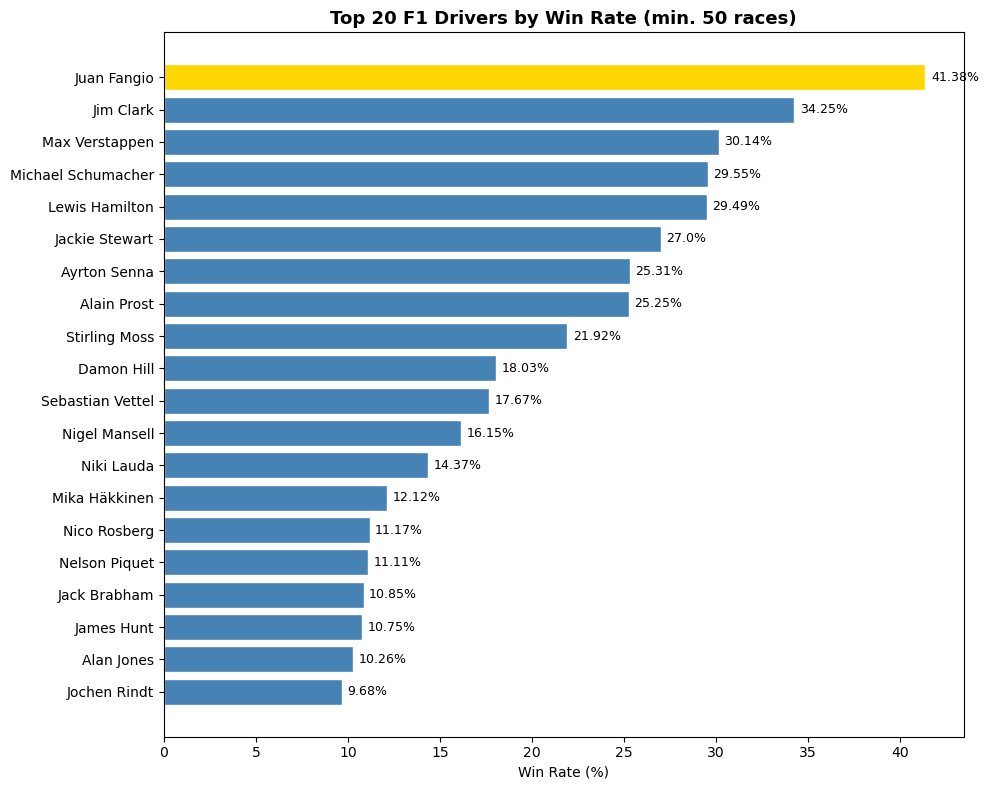

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv", low_memory=False)

win_rate = (
    df.groupby(["driver_forename", "driver_surname"])
    .agg(
        gare_disputate=("raceId", "count"),  # tutte le gare, inclusi ritiri
        vittorie=("finish_position", lambda x: (x == 1.0).sum()),
    )
    .reset_index()
)

win_rate["win_rate_%"] = (win_rate["vittorie"] / win_rate["gare_disputate"] * 100).round(2)
win_rate["pilota"] = win_rate["driver_forename"] + " " + win_rate["driver_surname"]
win_rate = win_rate[win_rate["gare_disputate"] >= 50].sort_values("win_rate_%", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(win_rate))]
ax.barh(win_rate["pilota"][::-1], win_rate["win_rate_%"][::-1], color=colors[::-1], edgecolor="white")
ax.set_title("Top 20 F1 Drivers by Win Rate (min. 50 races)", fontsize=13, fontweight="bold")
ax.set_xlabel("Win Rate (%)")
for i, val in enumerate(win_rate["win_rate_%"][::-1]):
    ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("win_rate_piloti.png", dpi=150)
plt.show()